Training Set Shape :  (60000, 28, 28)
Testing Set Shape :  (10000, 28, 28)


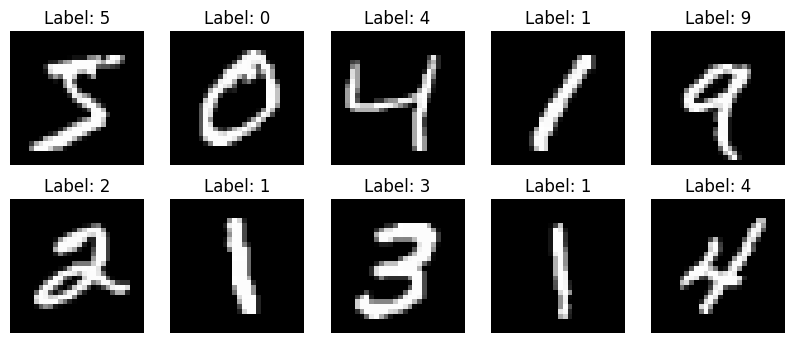

Epoch 1/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8528 - loss: 0.4856 - val_accuracy: 0.9494 - val_loss: 0.1749
Epoch 2/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9281 - loss: 0.2416 - val_accuracy: 0.9583 - val_loss: 0.1466
Epoch 3/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9423 - loss: 0.1996 - val_accuracy: 0.9622 - val_loss: 0.1265
Epoch 4/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9494 - loss: 0.1722 - val_accuracy: 0.9672 - val_loss: 0.1161
Epoch 5/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9530 - loss: 0.1560 - val_accuracy: 0.9665 - val_loss: 0.1173
Epoch 6/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9570 - loss: 0.1429 - val_accuracy: 0.9683 - val_loss: 0.1093
Epoch 7/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9597 - loss: 0.1334 - val_accuracy: 0.9707 - val_loss: 0.1076
Epoch 8/50
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9614 - loss: 0.1306 - 

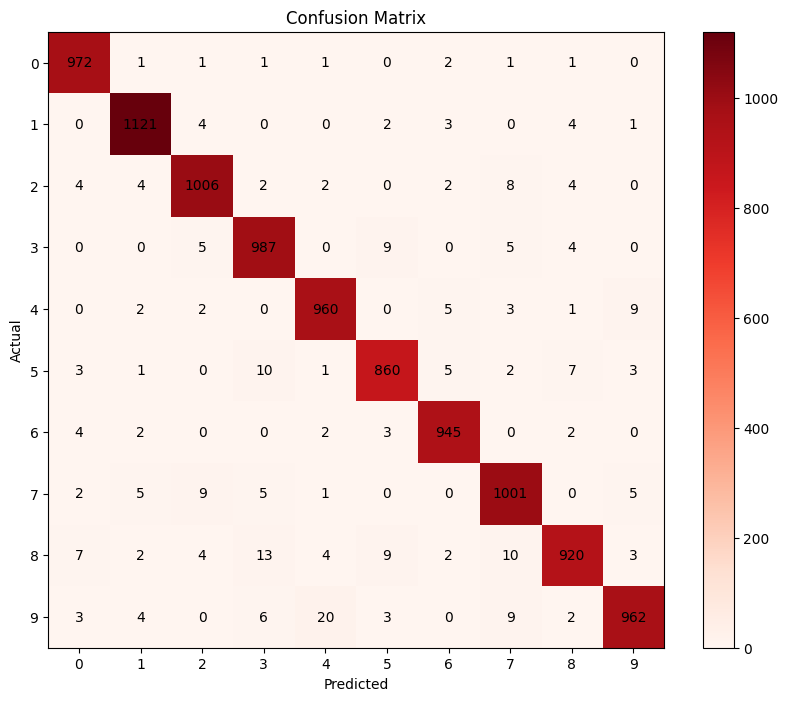

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score


# Loading Data and Split into test and train

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
print('Training Set Shape : ',X_train.shape)
print('Testing Set Shape : ',X_test.shape)

# Visualizing some data

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.show()

# Normalizing pixels

X_train_norm = X_train/255
X_test_norm = X_test/255

# Flattening

X_train_norm_f = X_train_norm.reshape(X_train_norm.shape[0],784)
X_test_norm_f = X_test_norm.reshape(X_test_norm.shape[0],784)

# Designing Neural Network Model

model = tf.keras.Sequential([
     tf.keras.layers.Dense(units=60,activation='relu'),
     tf.keras.layers.Dropout(0.2),
     tf.keras.layers.Dense(units=40,activation='relu'),
     tf.keras.layers.Dropout(0.2),
     tf.keras.layers.Dense(units=10,activation='linear')
])

model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.001),
    metrics=['accuracy']
)
model.fit(X_train_norm_f,y_train,epochs=50,validation_split=0.2)

# Prediction

logits = model(X_test_norm_f)
prob = tf.nn.softmax(logits)
y_pred = tf.argmax(prob,axis=1)

# evaluation

y_pred = y_pred.numpy()
print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
conf = confusion_matrix(y_test,y_pred)
print(f'\nConfusion Matrix : \n {conf}')
cla = classification_report(y_test,y_pred)
print(cla)

# Confusion Matrix HeatMap

plt.figure(figsize=(10,8))
plt.imshow(conf, cmap='Reds')
plt.colorbar()
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(range(10))
plt.yticks(range(10))
for i in range(10):
    for j in range(10):
        plt.text(j, i, conf[i,j], ha='center', va='center')
plt.show()


In [ ]:
# Save and download model
model.save('mnist_model.keras')

from google.colab import files
files.download('mnist_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>